## Exploratory Data Analysis

In [61]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [62]:
LOG_TRACKING_PATH = Path("../data/logs/tracking.csv")
COLLISION_FRAME = 752
COLLISION_OBJECT = 17

### Data Loading & Data Info

In [63]:
df = pd.read_csv(LOG_TRACKING_PATH)
df.head()

,frame,track_id,object_id,class_id,class_name,confidence,x1,y1,x2,y2,center_x,center_y,dx,dy,anomaly_score,zscore,stitched
0,0,1,1,2,car,0.875073,0.970940,1244.523682,287.477692,1518.335693,144.224316,1381.429688,NaN,NaN,NaN,NaN,False
1,1,1,1,2,car,0.874984,0.982015,1244.522095,287.485809,1518.330566,144.233912,1381.426331,0.009596,-0.003357,NaN,NaN,False
2,2,1,1,2,car,0.879042,1.002587,1244.513916,287.552856,1518.364990,144.277722,1381.439453,0.043810,0.013123,NaN,NaN,False
3,3,1,1,2,car,0.873027,0.983533,1244.441162,287.613953,1518.369507,144.298743,1381.405334,0.021021,-0.034119,0.005682,NaN,False
4,4,1,1,2,car,0.868689,0.957939,1244.382935,287.650269,1518.372559,144.304104,1381.377747,0.005361,-0.027588,0.019448,NaN,False


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10279 entries, 0 to 10278
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   frame          10279 non-null  int64  
 1   track_id       10279 non-null  int64  
 2   object_id      10279 non-null  int64  
 3   class_id       10279 non-null  int64  
 4   class_name     10279 non-null  str    
 5   confidence     10279 non-null  float64
 6   x1             10279 non-null  float64
 7   y1             10279 non-null  float64
 8   x2             10279 non-null  float64
 9   y2             10279 non-null  float64
 10  center_x       10279 non-null  float64
 11  center_y       10279 non-null  float64
 12  dx             10063 non-null  float64
 13  dy             10063 non-null  float64
 14  anomaly_score  9988 non-null   float64
 15  zscore         9917 non-null   float64
 16  stitched       10279 non-null  bool   
dtypes: bool(1), float64(11), int64(4), str(1)
memory usage: 1.3 M

In [65]:
df.describe()

,frame,track_id,object_id,class_id,confidence,x1,y1,x2,y2,center_x,center_y,dx,dy,anomaly_score,zscore
count,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10279.000000,10063.000000,10063.000000,9988.000000,9917.000000
mean,1023.380387,373.798327,15.807082,2.002919,0.703768,1046.873893,564.773958,1230.922160,693.473898,1138.898026,629.123928,-0.842723,-0.243609,0.907500,1.097104
std,373.826328,301.768390,10.424230,0.053948,0.190548,820.107113,305.744077,780.982773,382.871548,798.901896,343.535229,5.817671,2.258131,2.431592,6.234222
min,0.000000,1.000000,1.000000,2.000000,0.200277,0.287662,320.079559,286.705109,368.518494,143.716089,344.568405,-50.150146,-19.417816,0.000004,0.000205
25%,738.500000,166.000000,7.000000,2.000000,0.583633,557.157654,381.237808,649.251282,459.602539,603.102112,421.330345,-0.418106,-0.249161,0.056849,0.348800
50%,1056.000000,319.000000,17.000000,2.000000,0.759011,843.612793,431.632751,969.283936,498.674347,907.356750,470.632385,-0.000781,-0.003784,0.259162,0.630293
75%,1347.000000,612.000000,24.000000,2.000000,0.860106,2051.723999,551.163330,2180.327881,760.146515,2116.471222,655.854340,0.278320,0.184242,0.779951,0.980686
max,1599.000000,1078.000000,40.000000,3.000000,0.973004,2653.618896,1283.408325,2688.000000,1520.000000,2669.534790,1401.704163,47.233948,26.036224,42.407488,440.015694


### Dataset Overview

In [66]:
print(f"Frames: {df['frame'].min()} - {df['frame'].max()}")
print(f"Unique objects: {df['object_id'].nunique()}")
print(f"Unique tracks: {df['track_id'].nunique()}")
print(f"Detections count: {len(df)}")

Frames: 0 - 1599
Unique objects: 40
Unique tracks: 79
Detections count: 10279


In [67]:
df.groupby("class_name")["object_id"].nunique()

class_name
car           39
motorcycle     3
Name: object_id, dtype: int64

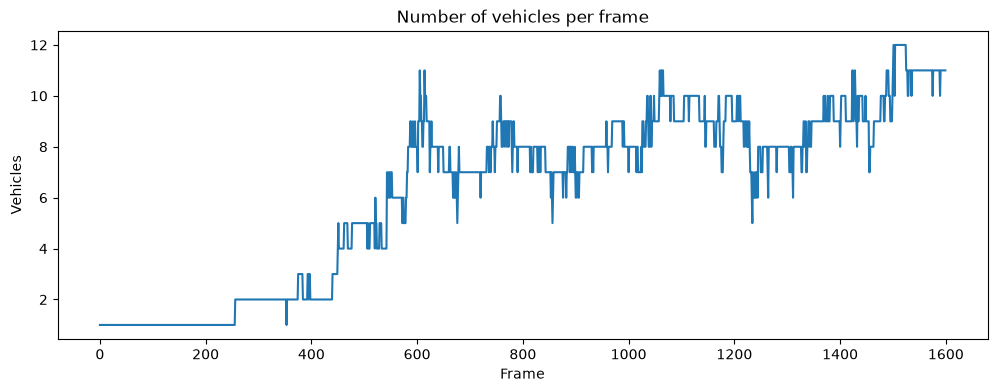

In [68]:
vehicles_per_frame = df.groupby("frame")["object_id"].nunique()

vehicles_per_frame.plot(
    figsize=(12, 4),
    title="Number of vehicles per frame"
)

plt.xlabel("Frame")
plt.ylabel("Vehicles")
plt.show()

### Tracking Analysis

In [69]:
track_stats = (
    df.groupby("object_id")
      .agg(
          unique_tracks=("track_id", "nunique"),
          first_frame=("frame", "min"),
          last_frame=("frame", "max"),
      )
      .sort_values("unique_tracks", ascending=False)
)

track_stats.head(10)

,unique_tracks,first_frame,last_frame
object_id,,,
12,19,596,1599
24,5,915,1599
17,4,678,1599
26,3,969,1599
23,3,885,1599
18,3,732,991
28,2,1035,1599
20,2,753,1442
13,2,605,898


Track stitching was introduced to reduce ID switches and preserve object identity when the tracker temporarily loses an object

### Trajectory Analysis

Collision car object id is 17

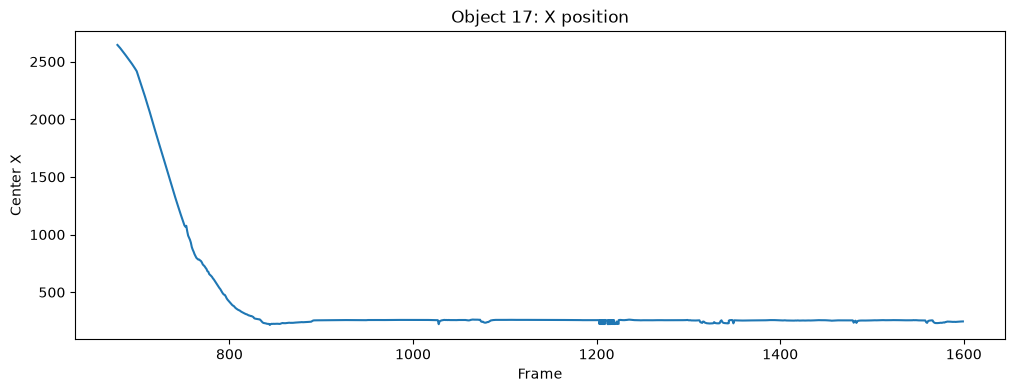

In [70]:
object_id = COLLISION_OBJECT

collision_object_df = df[df["object_id"] == object_id]

plt.figure(figsize=(12, 4))
plt.plot(collision_object_df["frame"], collision_object_df["center_x"])
plt.title(f"Object {object_id}: X position")
plt.xlabel("Frame")
plt.ylabel("Center X")
plt.show()

The trajectory visualization was also used to identify track stitching errors that produce artificial motion anomalies

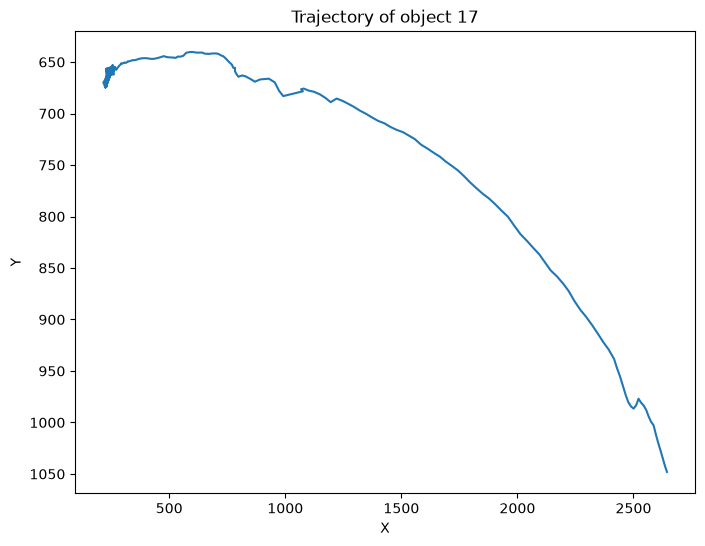

In [71]:
plt.figure(figsize=(8, 6))

plt.plot(
    collision_object_df["center_x"],
    collision_object_df["center_y"],
)

plt.gca().invert_yaxis()

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Trajectory of object {object_id}")
plt.show()

### Exploring **dx**, **dy** (px / frame) features

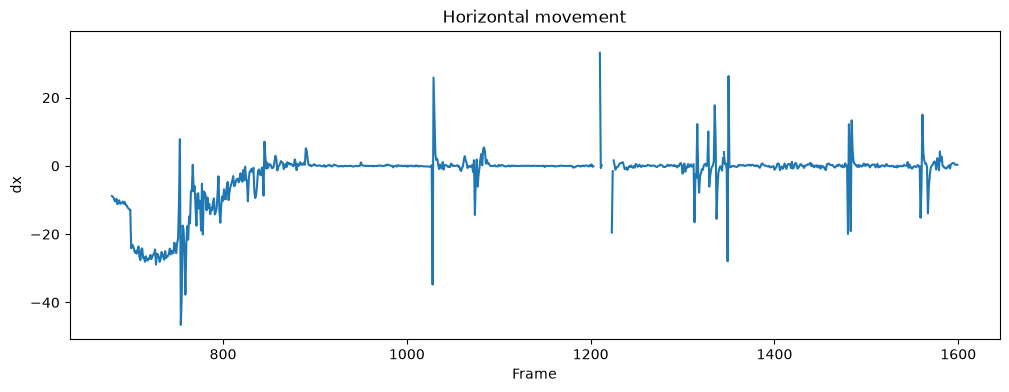

In [72]:
collision_object_df = df[df["object_id"] == COLLISION_OBJECT].copy()

plt.figure(figsize=(12, 4))

plt.plot(
    collision_object_df["frame"],
    collision_object_df["dx"],
)

plt.xlabel("Frame")
plt.ylabel("dx")
plt.title("Horizontal movement")
plt.show()

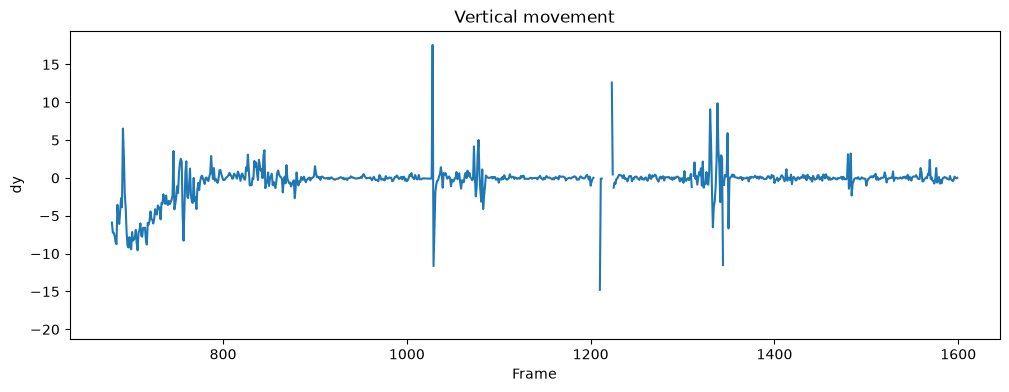

In [73]:
plt.figure(figsize=(12, 4))

plt.plot(
    collision_object_df["frame"],
    collision_object_df["dy"],
)

plt.xlabel("Frame")
plt.ylabel("dy")
plt.title("Vertical movement")
plt.show()

**dx** contains a noticeable displacement pattern around the collision than **dy**

### Baseline Anomaly Score |dx - rolling_mean_dx|

In [74]:
WINDOW_SIZE = 7
collision_object_df["rolling_mean_dx"] = collision_object_df["dx"].shift(1).rolling(WINDOW_SIZE, min_periods=2).mean()

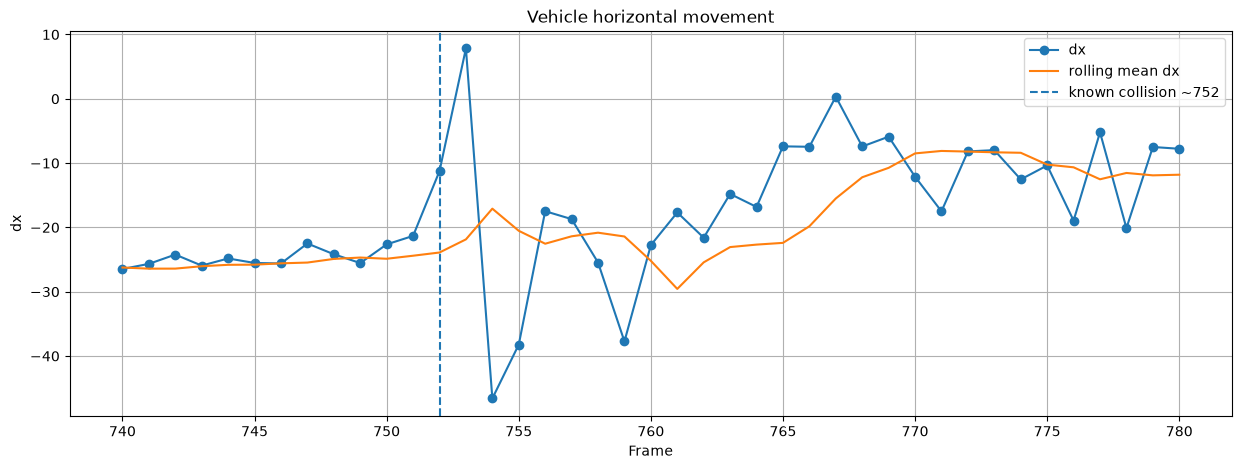

In [75]:
collision_window = collision_object_df[
    collision_object_df["frame"].between(740, 780)
].copy()

plt.figure(figsize=(15, 5))

plt.plot(
    collision_window["frame"],
    collision_window["dx"],
    marker="o",
    label="dx"
)

plt.plot(
    collision_window["frame"],
    collision_window["rolling_mean_dx"],
    label="rolling mean dx"
)

plt.axvline(
    COLLISION_FRAME,
    linestyle="--",
    label="known collision ~752"
)

plt.xlabel("Frame")
plt.ylabel("dx")
plt.title("Vehicle horizontal movement")
plt.legend()
plt.grid()

plt.show()

In [76]:
THRESHOLD_WINDOW_SIZE = 30
QUANTILE = 0.95
MIN_COUNT_OF_SCORES = 5

In [77]:
collision_object_df["threshold"] = (
    collision_object_df["anomaly_score"]
    .rolling(
        WINDOW_SIZE,
        min_periods=MIN_COUNT_OF_SCORES
    )
    .quantile(QUANTILE)
)

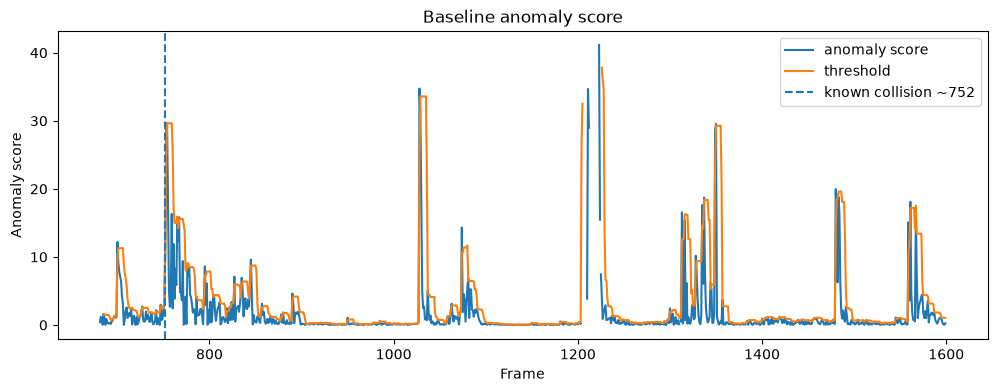

In [78]:
plt.figure(figsize=(12, 4))

plt.plot(
    collision_object_df["frame"],
    collision_object_df["anomaly_score"],
    label="anomaly score"
)

plt.plot(
    collision_object_df["frame"],
    collision_object_df["threshold"],
    label="threshold"
)

plt.axvline(
    COLLISION_FRAME,
    linestyle="--",
    label="known collision ~752"
)

plt.xlabel("Frame")
plt.ylabel("Anomaly score")
plt.title("Baseline anomaly score")
plt.legend()
plt.show()

In [79]:
score_collision_window = collision_object_df[
    collision_object_df["frame"].between(740, 780)
].copy()

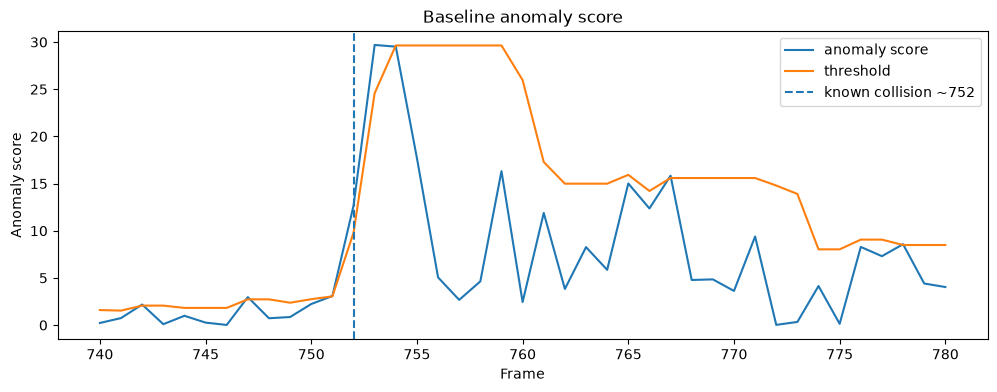

In [80]:
plt.figure(figsize=(12, 4))

plt.plot(
    score_collision_window["frame"],
    score_collision_window["anomaly_score"],
    label="anomaly score"
)

plt.plot(
    score_collision_window["frame"],
    score_collision_window["threshold"],
    label="threshold"
)

plt.axvline(
    COLLISION_FRAME,
    linestyle="--",
    label="known collision ~752"
)

plt.xlabel("Frame")
plt.ylabel("Anomaly score")
plt.title("Baseline anomaly score")
plt.legend()
plt.show()

Distribution of Anomaly Score

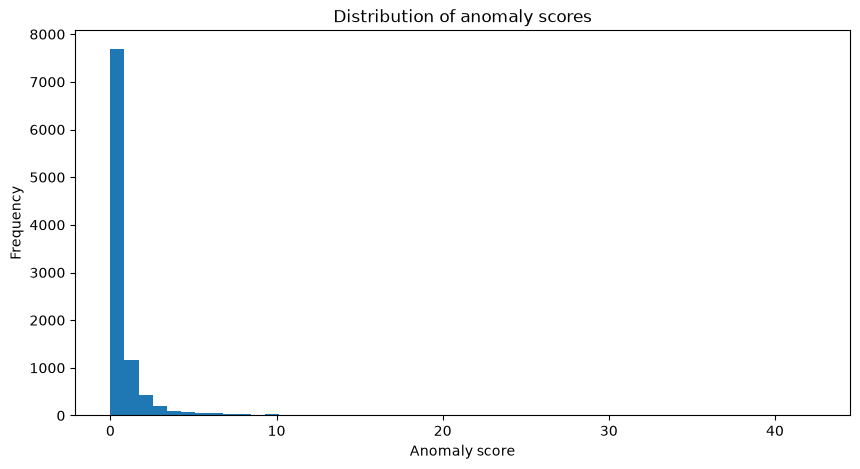

In [81]:
scores = df["anomaly_score"].dropna()

plt.figure(figsize=(10, 5))

plt.hist(scores, bins=50)

plt.xlabel("Anomaly score")
plt.ylabel("Frequency")
plt.title("Distribution of anomaly scores")
plt.show()

### Z-Score Exploring

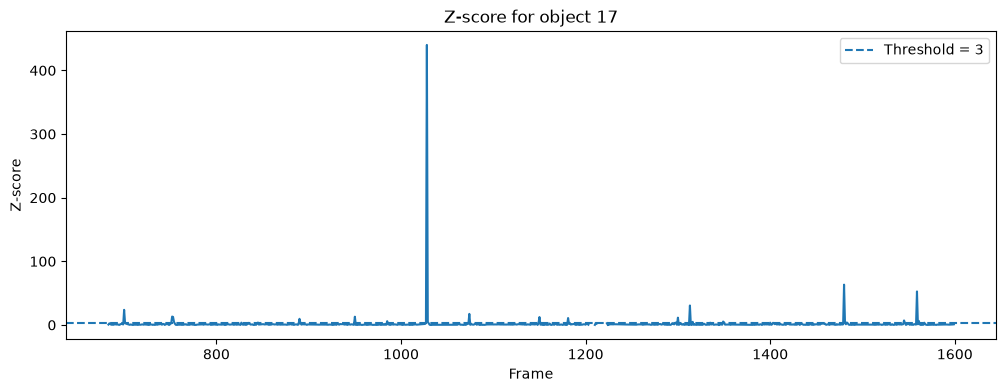

In [82]:
collision_object_df = df[df["object_id"] == COLLISION_OBJECT]

plt.figure(figsize=(12, 4))

plt.plot(
    collision_object_df["frame"],
    collision_object_df["zscore"],
)

plt.axhline(
    3.0,
    linestyle="--",
    label="Threshold = 3"
)

plt.xlabel("Frame")
plt.ylabel("Z-score")
plt.title(f"Z-score for object {COLLISION_OBJECT}")
plt.legend()
plt.show()

Z-Score around the collision

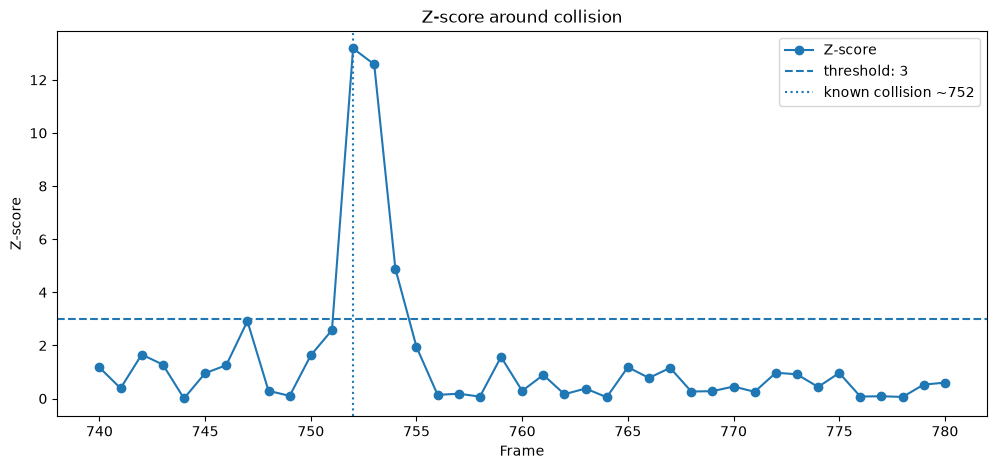

In [83]:
plt.figure(figsize=(12, 5))

plt.plot(
    collision_window["frame"],
    collision_window["zscore"],
    marker="o",
    label="Z-score"
)

plt.axhline(3.0, 
            linestyle="--",
            label="threshold: 3"
            )

plt.axvline(
    COLLISION_FRAME,
    linestyle=":",
    label="known collision ~752"
)

plt.xlabel("Frame")
plt.ylabel("Z-score")
plt.title("Z-score around collision")
plt.legend()
plt.show()

### Additionaly

#### Z-Score of **dy** Anomaly Score

In [84]:
df["rolling_mean_dx"] = (
    df.groupby("object_id")["dx"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=3).mean()
      )
    )

df["dx_deviation"] = (
    df["dx"] -
    df["rolling_mean_dx"]
)

df["abs_dx_deviation"] = (
    df["dx_deviation"].abs()
)

In [85]:
df["rolling_mean_dy"] = (
    df.groupby("object_id")["dy"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=3).mean()
      )
    )

df["dy_deviation"] = (
    df["dy"] -
    df["rolling_mean_dy"]
)

df["abs_dy_deviation"] = (
    df["dy_deviation"].abs()
)

In [86]:
collision_object_df = df[df["object_id"] == COLLISION_OBJECT].copy()

history_dx = collision_object_df["abs_dx_deviation"].shift(1)

rolling_mean_dx = history_dx.rolling(
    THRESHOLD_WINDOW_SIZE,
    min_periods=MIN_COUNT_OF_SCORES
).mean()

rolling_std_dx = history_dx.rolling(
    THRESHOLD_WINDOW_SIZE,
    min_periods=MIN_COUNT_OF_SCORES
).std()

collision_object_df["zscore_dx"] = (
    (collision_object_df["abs_dy_deviation"] - rolling_mean_dx).abs()
    / rolling_std_dx
)

In [87]:


history_dy = collision_object_df["abs_dy_deviation"].shift(1)

rolling_mean_dy = history_dy.rolling(
    THRESHOLD_WINDOW_SIZE,
    min_periods=MIN_COUNT_OF_SCORES
).mean()

rolling_std_dy = history_dy.rolling(
    THRESHOLD_WINDOW_SIZE,
    min_periods=MIN_COUNT_OF_SCORES
).std()

collision_object_df["zscore_dy"] = (
    (collision_object_df["abs_dy_deviation"] - rolling_mean_dy).abs()
    / rolling_std_dy
)

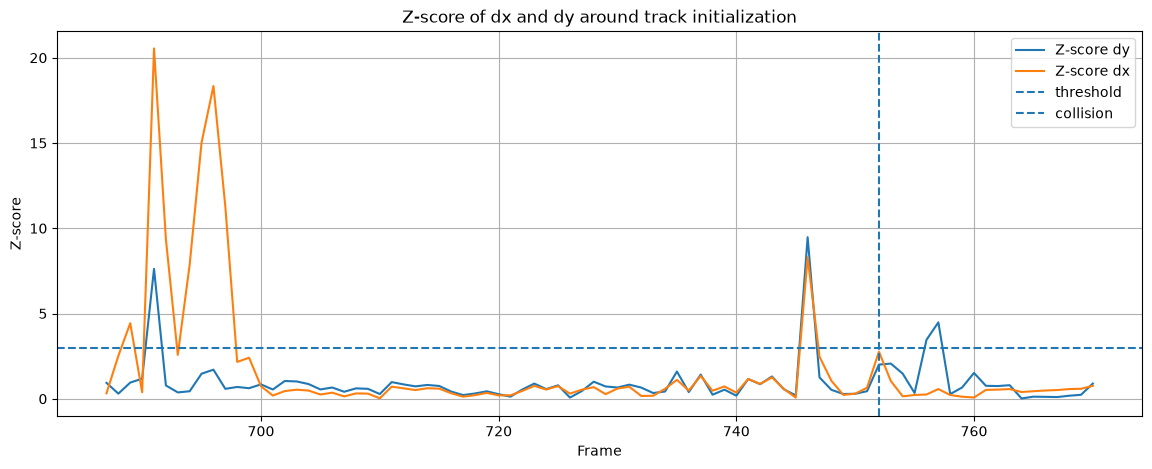

In [90]:
collision_window = collision_object_df[
    collision_object_df["frame"].between(600, 770)
].copy()

plt.figure(figsize=(14, 5))

plt.plot(
    collision_window["frame"],
    collision_window["zscore_dy"],
    label="Z-score dy"
)

plt.plot(
    collision_window["frame"],
    collision_window["zscore_dx"],
    label="Z-score dx"
)

plt.axhline(
    3.0,
    linestyle="--",
    label="threshold"
)

plt.axvline(
    752,
    linestyle="--",
    label="collision"
)

plt.xlabel("Frame")
plt.ylabel("Z-score")
plt.title("Z-score of dx and dy around track initialization")
plt.legend()
plt.grid()
plt.show()

As we can see, the Z-score of **dy** is more stable than **dx** during track initialization

### Collision Exploring

In [89]:
collision_window = df[
    (df["object_id"] == COLLISION_OBJECT)
    & (df["frame"].between(
        COLLISION_FRAME - 10,
        COLLISION_FRAME + 10
    ))
]

collision_window[
    [
        "frame",
        "dx",
        "anomaly_score",
        "zscore",
    ]
]

,frame,dx,anomaly_score,zscore
2602,742,-24.230774,2.181048,1.656253
2611,743,-25.943634,0.096649,1.278245
2621,744,-24.833008,0.987440,0.003490
2630,745,-25.534058,0.265071,0.954277
2639,746,-25.609375,0.017042,1.254789
2648,747,-22.505188,2.965293,2.913690
2656,748,-24.178131,0.726283,0.290592
2664,749,-25.547913,0.857317,0.100512
2672,750,-22.643524,2.235234,1.627709
2680,751,-21.324799,3.082515,2.574726


## Conclusions

This investigation was conducted to detect vehicle collisions in traffic video.
Due to unstable detection of the second vehicle involved in the collision, several approaches were investigated to identify the collision from the behavior of the first vehicle.

The first approach is based on the absolute deviation of **dx** from the **rolling mean of dx**, using a window size of 7.

The experiments showed that the raw horizontal displacement anomaly score produces a significant number of false positives, mainly due to normal vehicle acceleration, detection noise, and tracking instability.

Several additional motion features were investigated, including vertical displacement, speed, and acceleration. They did not provide sufficient improvement for the evaluated video and were therefore not included in the final pipeline.

Angle and direction changes were also explored as motion features. However, due to unstable bounding box detection, these features produced unreliable results and were considered unsuitable for the final approach.

**Z-score** calculated over a rolling window provided a more stable anomaly measure across objects with different motion patterns. A threshold of **3.0** was selected for anomaly detection.

The final pipeline consists of:

- YOLO for vehicle detection
- ByteTrack for multi-object tracking
- TrackStitcher for track ID recovery
- trajectory analysis based on horizontal displacement
- rolling Z-score anomaly detection
- anomaly threshold of 3.0
- temporal event filtering